In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

# Reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Paths
PROJECT_DIR = Path("..")
DATA_DIR = PROJECT_DIR / "data"
SYNTHETIC_DIR = DATA_DIR / "synthetic"
FIGURES_DIR = PROJECT_DIR / "figures" / "04_time_series_trends"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = SYNTHETIC_DIR / "microct_statistics_dataset.csv"

print("Data path:", DATA_PATH.resolve())
print("Figures directory:", FIGURES_DIR.resolve())
print("Results directory:", RESULTS_DIR.resolve())

Data path: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\data\synthetic\microct_statistics_dataset.csv
Figures directory: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\figures\04_time_series_trends
Results directory: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results


In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 37)


,sample_id,time_index,batch_id,protocol,is_outlier,voltage_kV,current_uA,exposure_ms,n_projections,voxel_size_um,...,cnr_drifted,pore_detectability,detectability_score,segmentation_bias,segmentation_abs_error,estimated_porosity,porosity_error,abs_porosity_error,estimated_mean_pore_diameter_um,quality_score
0,1,0,2,B_optimized,False,139.779264,79.740205,556.875111,1661,67.210426,...,11.970542,4.498315,0.817323,-0.000816,0.040911,0.028641,-0.015902,0.015902,287.169132,68.535130
1,2,1,16,B_optimized,False,133.584995,88.224429,509.266539,1568,58.500142,...,11.447199,2.712877,0.428708,-0.018846,0.058534,0.024571,-0.030900,0.030900,155.735321,60.565095
2,3,2,14,B_optimized,False,133.159816,79.573577,669.746240,1346,56.410341,...,13.206688,1.589025,0.196080,-0.026190,0.072801,0.027155,-0.021571,0.021571,77.601924,53.103840
3,4,3,9,B_optimized,False,135.628140,79.754049,671.113602,1778,53.400963,...,13.997532,3.189257,0.547174,-0.019235,0.052760,0.007369,-0.015688,0.015688,143.422889,66.903072
4,5,4,9,B_optimized,False,145.179520,75.327765,803.071348,1107,54.595544,...,9.636927,10.265431,0.999301,0.005620,0.038226,0.050214,0.003226,0.003226,546.998549,72.247540


In [3]:
# ------------------------------------------------------------
# Sort dataset by acquisition time
# ------------------------------------------------------------

df = df.sort_values("time_index").reset_index(drop=True)

print("Time index range:")
print(df["time_index"].min(), "to", df["time_index"].max())

print("\nProtocol counts:")
print(df["protocol"].value_counts())

print("\nOutlier counts:")
print(df["is_outlier"].value_counts())

print("\nSelected columns:")
selected_columns = [
    "time_index",
    "protocol",
    "is_outlier",
    "detector_drift",
    "relative_noise_drifted",
    "snr_drifted",
    "cnr_drifted",
    "segmentation_abs_error",
    "abs_porosity_error",
    "quality_score"
]

df[selected_columns].head()

Time index range:
0 to 999

Protocol counts:
protocol
A_standard     509
B_optimized    491
Name: count, dtype: int64

Outlier counts:
is_outlier
False    970
True      30
Name: count, dtype: int64

Selected columns:


,time_index,protocol,is_outlier,detector_drift,relative_noise_drifted,snr_drifted,cnr_drifted,segmentation_abs_error,abs_porosity_error,quality_score
0,0,B_optimized,False,1.00000,0.055184,3.523422,11.970542,0.040911,0.015902,68.535130
1,1,B_optimized,False,1.00025,0.054451,4.757541,11.447199,0.058534,0.030900,60.565095
2,2,B_optimized,False,1.00050,0.050746,3.658181,13.206688,0.072801,0.021571,53.103840
3,3,B_optimized,False,1.00075,0.047317,4.147451,13.997532,0.052760,0.015688,66.903072
4,4,B_optimized,False,1.00100,0.065136,3.720241,9.636927,0.038226,0.003226,72.247540


In [4]:
# ------------------------------------------------------------
# Time-series metrics
# ------------------------------------------------------------

time_column = "time_index"

time_series_metrics = [
    "relative_noise_drifted",
    "snr_drifted",
    "cnr_drifted",
    "segmentation_abs_error",
    "abs_porosity_error",
    "quality_score",
]

metric_directions = {
    "relative_noise_drifted": "lower_is_better",
    "snr_drifted": "higher_is_better",
    "cnr_drifted": "higher_is_better",
    "segmentation_abs_error": "lower_is_better",
    "abs_porosity_error": "lower_is_better",
    "quality_score": "higher_is_better",
}

df[time_series_metrics].describe()

,relative_noise_drifted,snr_drifted,cnr_drifted,segmentation_abs_error,abs_porosity_error,quality_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000
mean,0.095527,2.175168,8.188166,0.071984,1.433765e-02,48.613287
std,0.038823,1.043825,3.047683,0.023123,1.130710e-02,15.175519
min,0.033087,0.413907,1.984404,0.027438,7.663868e-07,8.227662
25%,0.062592,1.339998,5.497135,0.052584,6.025201e-03,35.916795
50%,0.091924,1.965652,7.399942,0.070289,1.159697e-02,47.750985
75%,0.123622,2.869105,10.745729,0.090025,1.966800e-02,61.217733
max,0.344169,6.301351,20.752239,0.174409,6.401317e-02,88.883976


In [5]:
# ------------------------------------------------------------
# Helper function: time-series plot with rolling mean
# ------------------------------------------------------------

def plot_time_series_with_rolling_mean(
    data,
    metric,
    window=50,
    mark_outliers=True,
    save=True
):
    """
    Plot a metric over time with a rolling mean.
    """
    rolling_column = f"{metric}_rolling_mean_{window}"

    data = data.copy()
    data[rolling_column] = data[metric].rolling(
        window=window,
        center=True,
        min_periods=10
    ).mean()

    plt.figure(figsize=(9, 4))

    plt.scatter(
        data[time_column],
        data[metric],
        alpha=0.35,
        s=14,
        label="observations"
    )

    plt.plot(
        data[time_column],
        data[rolling_column],
        linewidth=2,
        label=f"rolling mean ({window})"
    )

    if mark_outliers:
        outlier_data = data[data["is_outlier"]]
        plt.scatter(
            outlier_data[time_column],
            outlier_data[metric],
            s=45,
            marker="x",
            label="synthetic outliers"
        )

    plt.xlabel("Time index")
    plt.ylabel(metric)
    plt.title(f"Time-series trend: {metric}")
    plt.legend()
    plt.tight_layout()

    if save:
        output_path = FIGURES_DIR / f"time_series_{metric}.png"
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {output_path}")

    plt.show()

Saved: ..\figures\04_time_series_trends\time_series_relative_noise_drifted.png


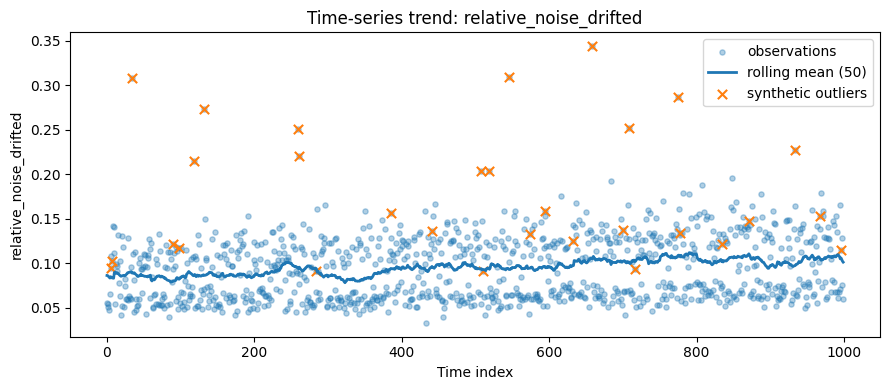

Saved: ..\figures\04_time_series_trends\time_series_snr_drifted.png


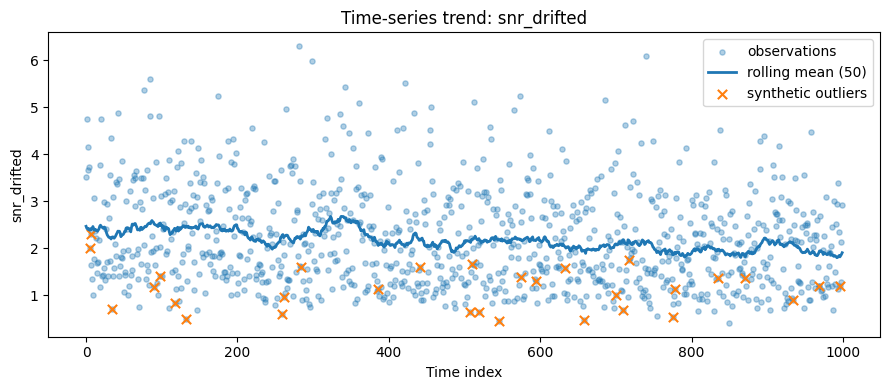

Saved: ..\figures\04_time_series_trends\time_series_cnr_drifted.png


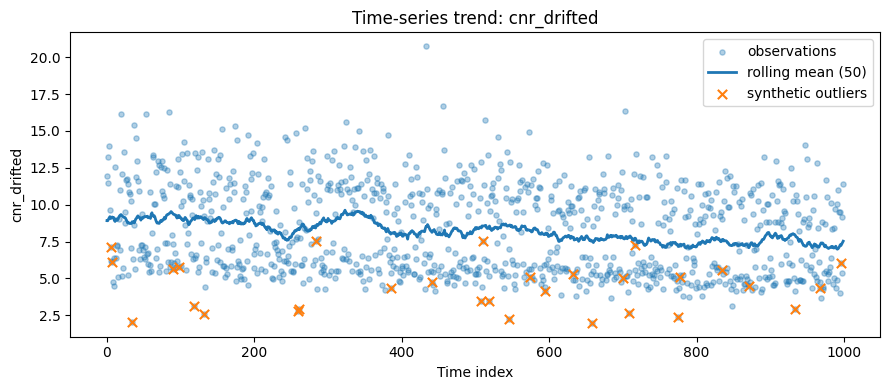

Saved: ..\figures\04_time_series_trends\time_series_segmentation_abs_error.png


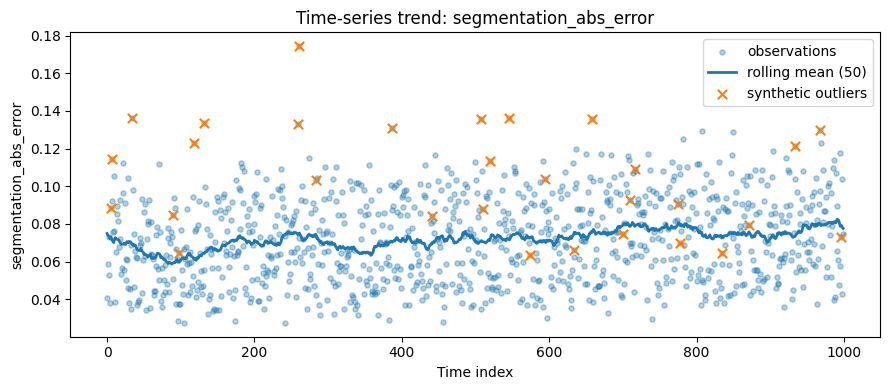

Saved: ..\figures\04_time_series_trends\time_series_abs_porosity_error.png


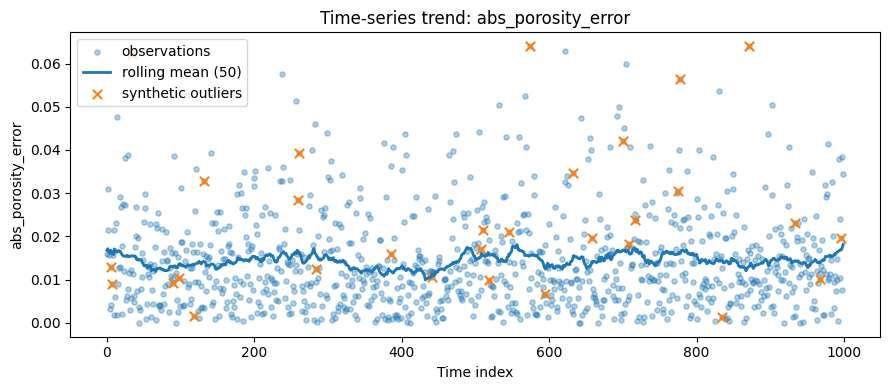

Saved: ..\figures\04_time_series_trends\time_series_quality_score.png


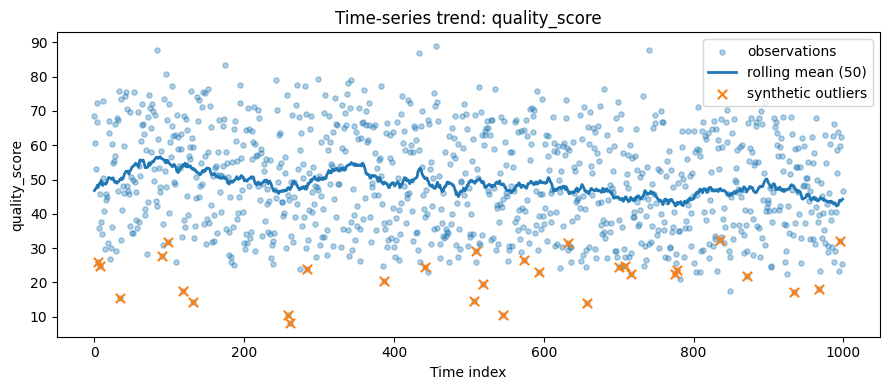

In [6]:
# ------------------------------------------------------------
# Plot main time-series trends
# ------------------------------------------------------------

for metric in time_series_metrics:
    plot_time_series_with_rolling_mean(
        data=df,
        metric=metric,
        window=50,
        mark_outliers=True,
        save=True
    )

In [7]:
# ------------------------------------------------------------
# Linear trend estimation over time
# ------------------------------------------------------------

trend_rows = []

for metric in time_series_metrics:
    x = df[time_column].values
    y = df[metric].values

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    trend_rows.append({
        "metric": metric,
        "slope_per_time_step": slope,
        "slope_per_100_steps": slope * 100,
        "intercept": intercept,
        "r_value": r_value,
        "r_squared": r_value ** 2,
        "p_value": p_value,
        "std_err": std_err,
        "direction": metric_directions[metric],
    })

trend_df = pd.DataFrame(trend_rows)

trend_df.round(6)

,metric,slope_per_time_step,slope_per_100_steps,intercept,r_value,r_squared,p_value,std_err,direction
0,relative_noise_drifted,0.000024,0.002388,0.083602,0.177618,0.031548,0.000000,0.000004,lower_is_better
1,snr_drifted,-0.000570,-0.057035,2.460059,-0.157813,0.024905,0.000001,0.000113,higher_is_better
2,cnr_drifted,-0.001983,-0.198291,9.178628,-0.187914,0.035312,0.000000,0.000328,higher_is_better
3,segmentation_abs_error,0.000013,0.001256,0.065712,0.156853,0.024603,0.000001,0.000003,lower_is_better
4,abs_porosity_error,0.000001,0.000103,0.013823,0.026319,0.000693,0.405760,0.000001,lower_is_better
5,quality_score,-0.008098,-0.809787,52.658175,-0.154118,0.023752,0.000001,0.001643,higher_is_better


In [8]:
# ------------------------------------------------------------
# Rolling statistics
# ------------------------------------------------------------

rolling_window = 50

rolling_df = df.copy()

for metric in time_series_metrics:
    rolling_df[f"{metric}_rolling_mean_{rolling_window}"] = (
        rolling_df[metric]
        .rolling(window=rolling_window, center=True, min_periods=10)
        .mean()
    )

    rolling_df[f"{metric}_rolling_std_{rolling_window}"] = (
        rolling_df[metric]
        .rolling(window=rolling_window, center=True, min_periods=10)
        .std()
    )

rolling_columns = [
    time_column,
    "protocol",
    "is_outlier",
]

for metric in time_series_metrics:
    rolling_columns.extend([
        metric,
        f"{metric}_rolling_mean_{rolling_window}",
        f"{metric}_rolling_std_{rolling_window}",
    ])

rolling_df[rolling_columns].head()

,time_index,protocol,is_outlier,relative_noise_drifted,relative_noise_drifted_rolling_mean_50,relative_noise_drifted_rolling_std_50,snr_drifted,snr_drifted_rolling_mean_50,snr_drifted_rolling_std_50,cnr_drifted,...,cnr_drifted_rolling_std_50,segmentation_abs_error,segmentation_abs_error_rolling_mean_50,segmentation_abs_error_rolling_std_50,abs_porosity_error,abs_porosity_error_rolling_mean_50,abs_porosity_error_rolling_std_50,quality_score,quality_score_rolling_mean_50,quality_score_rolling_std_50
0,0,B_optimized,False,0.055184,0.086397,0.032041,3.523422,2.468295,1.145924,11.970542,...,3.409472,0.040911,0.074915,0.022103,0.015902,0.016763,0.011890,68.535130,46.798942,15.759731
1,1,B_optimized,False,0.054451,0.086247,0.031403,4.757541,2.424213,1.145051,11.447199,...,3.340681,0.058534,0.073967,0.022189,0.030900,0.017163,0.011827,60.565095,47.105831,15.520408
2,2,B_optimized,False,0.050746,0.085258,0.031219,3.658181,2.423797,1.122817,13.206688,...,3.317733,0.072801,0.073502,0.021892,0.021571,0.016726,0.011818,53.103840,47.415210,15.303681
3,3,B_optimized,False,0.047317,0.084359,0.031002,4.147451,2.398248,1.110090,13.997532,...,3.296352,0.052760,0.073050,0.021615,0.015688,0.016351,0.011765,66.903072,47.753263,15.123767
4,4,B_optimized,False,0.065136,0.083496,0.030797,3.720241,2.416735,1.094624,9.636927,...,3.264893,0.038226,0.072111,0.021820,0.003226,0.016058,0.011660,72.247540,48.384488,15.235300


In [9]:
# ------------------------------------------------------------
# Control limits and statistical outlier detection
# ------------------------------------------------------------

control_limit_rows = []
detected_outlier_columns = []

for metric in time_series_metrics:
    mean_value = df[metric].mean()
    std_value = df[metric].std()

    lower_limit = mean_value - 3 * std_value
    upper_limit = mean_value + 3 * std_value

    detected_column = f"{metric}_detected_outlier"
    detected_outlier_columns.append(detected_column)

    df[detected_column] = (
        (df[metric] < lower_limit) |
        (df[metric] > upper_limit)
    )

    control_limit_rows.append({
        "metric": metric,
        "mean": mean_value,
        "std": std_value,
        "lower_control_limit": lower_limit,
        "upper_control_limit": upper_limit,
        "n_detected_outliers": df[detected_column].sum(),
        "detected_outlier_rate": df[detected_column].mean(),
        "direction": metric_directions[metric],
    })

control_limits_df = pd.DataFrame(control_limit_rows)

control_limits_df.round(6)

,metric,mean,std,lower_control_limit,upper_control_limit,n_detected_outliers,detected_outlier_rate,direction
0,relative_noise_drifted,0.095527,0.038823,-0.020941,0.211995,10,0.010,lower_is_better
1,snr_drifted,2.175168,1.043825,-0.956308,5.306643,7,0.007,higher_is_better
2,cnr_drifted,8.188166,3.047683,-0.954882,17.331215,1,0.001,higher_is_better
3,segmentation_abs_error,0.071984,0.023123,0.002616,0.141352,1,0.001,lower_is_better
4,abs_porosity_error,0.014338,0.011307,-0.019584,0.048259,14,0.014,lower_is_better
5,quality_score,48.613287,15.175519,3.086732,94.139843,0,0.000,higher_is_better


In [10]:
# ------------------------------------------------------------
# Compare detected outliers with synthetic outlier labels
# ------------------------------------------------------------

outlier_comparison_rows = []

for metric, detected_column in zip(time_series_metrics, detected_outlier_columns):
    detected = df[detected_column].astype(bool)
    synthetic = df["is_outlier"].astype(bool)

    true_positives = (detected & synthetic).sum()
    false_positives = (detected & ~synthetic).sum()
    false_negatives = (~detected & synthetic).sum()
    true_negatives = (~detected & ~synthetic).sum()

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else np.nan
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else np.nan

    outlier_comparison_rows.append({
        "metric": metric,
        "true_positives": true_positives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "true_negatives": true_negatives,
        "precision": precision,
        "recall": recall,
    })

outlier_comparison_df = pd.DataFrame(outlier_comparison_rows)

outlier_comparison_df.round(4)

,metric,true_positives,false_positives,false_negatives,true_negatives,precision,recall
0,relative_noise_drifted,10,0,20,970,1.0000,0.3333
1,snr_drifted,0,7,30,963,0.0000,0.0000
2,cnr_drifted,0,1,30,969,0.0000,0.0000
3,segmentation_abs_error,1,0,29,970,1.0000,0.0333
4,abs_porosity_error,4,10,26,960,0.2857,0.1333
5,quality_score,0,0,30,970,NaN,0.0000


In [11]:
# ------------------------------------------------------------
# Percentile-based outlier detection
# ------------------------------------------------------------

percentile_rows = []
percentile_detected_columns = []

lower_percentile = 3
upper_percentile = 97

for metric in time_series_metrics:
    direction = metric_directions[metric]

    detected_column = f"{metric}_percentile_outlier"
    percentile_detected_columns.append(detected_column)

    if direction == "lower_is_better":
        # High values are bad
        threshold = np.percentile(df[metric], upper_percentile)
        df[detected_column] = df[metric] > threshold
        rule = f"> P{upper_percentile}"

    else:
        # Low values are bad
        threshold = np.percentile(df[metric], lower_percentile)
        df[detected_column] = df[metric] < threshold
        rule = f"< P{lower_percentile}"

    percentile_rows.append({
        "metric": metric,
        "direction": direction,
        "rule": rule,
        "threshold": threshold,
        "n_detected_outliers": df[detected_column].sum(),
        "detected_outlier_rate": df[detected_column].mean(),
    })

percentile_limits_df = pd.DataFrame(percentile_rows)

percentile_limits_df.round(6)

,metric,direction,rule,threshold,n_detected_outliers,detected_outlier_rate
0,relative_noise_drifted,lower_is_better,> P97,0.161430,30,0.03
1,snr_drifted,higher_is_better,< P3,0.808522,30,0.03
2,cnr_drifted,higher_is_better,< P3,4.235763,30,0.03
3,segmentation_abs_error,lower_is_better,> P97,0.113444,30,0.03
4,abs_porosity_error,lower_is_better,> P97,0.041000,30,0.03
5,quality_score,higher_is_better,< P3,24.615024,30,0.03


In [12]:
# ------------------------------------------------------------
# Compare percentile outliers with synthetic outlier labels
# ------------------------------------------------------------

percentile_comparison_rows = []

for metric, detected_column in zip(time_series_metrics, percentile_detected_columns):
    detected = df[detected_column].astype(bool)
    synthetic = df["is_outlier"].astype(bool)

    true_positives = (detected & synthetic).sum()
    false_positives = (detected & ~synthetic).sum()
    false_negatives = (~detected & synthetic).sum()
    true_negatives = (~detected & ~synthetic).sum()

    precision = (
        true_positives / (true_positives + false_positives)
        if (true_positives + false_positives) > 0
        else np.nan
    )

    recall = (
        true_positives / (true_positives + false_negatives)
        if (true_positives + false_negatives) > 0
        else np.nan
    )

    percentile_comparison_rows.append({
        "metric": metric,
        "true_positives": true_positives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "true_negatives": true_negatives,
        "precision": precision,
        "recall": recall,
    })

percentile_comparison_df = pd.DataFrame(percentile_comparison_rows)

percentile_comparison_df.round(4)

,metric,true_positives,false_positives,false_negatives,true_negatives,precision,recall
0,relative_noise_drifted,12,18,18,952,0.4000,0.4000
1,snr_drifted,9,21,21,949,0.3000,0.3000
2,cnr_drifted,13,17,17,953,0.4333,0.4333
3,segmentation_abs_error,12,18,18,952,0.4000,0.4000
4,abs_porosity_error,5,25,25,945,0.1667,0.1667
5,quality_score,18,12,12,958,0.6000,0.6000


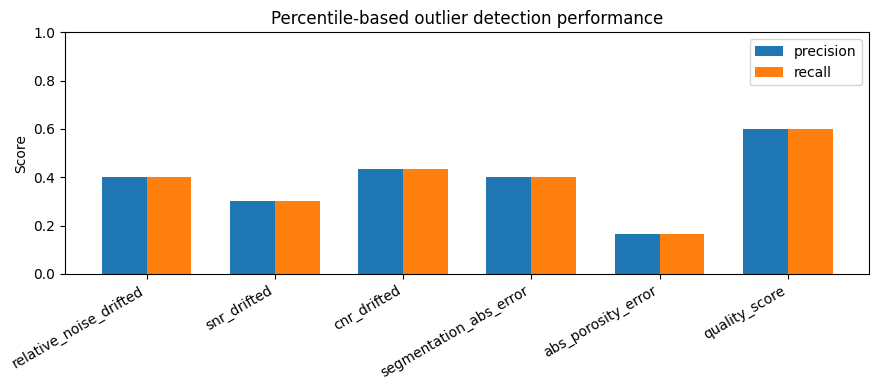

In [13]:
# ------------------------------------------------------------
# Plot percentile-based outlier detection performance
# ------------------------------------------------------------

plot_df = percentile_comparison_df.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 4))

plt.bar(
    x - width / 2,
    plot_df["precision"],
    width,
    label="precision"
)

plt.bar(
    x + width / 2,
    plot_df["recall"],
    width,
    label="recall"
)

plt.xticks(x, plot_df["metric"], rotation=30, ha="right")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Percentile-based outlier detection performance")
plt.legend()

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "percentile_outlier_detection_precision_recall.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [14]:
# ------------------------------------------------------------
# Save time-series analysis outputs
# ------------------------------------------------------------

trend_path = RESULTS_DIR / "04_time_series_linear_trends.csv"
rolling_path = RESULTS_DIR / "04_time_series_rolling_statistics.csv"
control_limits_path = RESULTS_DIR / "04_control_limits_3sigma.csv"
control_comparison_path = RESULTS_DIR / "04_control_limits_3sigma_outlier_comparison.csv"
percentile_limits_path = RESULTS_DIR / "04_percentile_outlier_thresholds.csv"
percentile_comparison_path = RESULTS_DIR / "04_percentile_outlier_detection_comparison.csv"

trend_df.to_csv(trend_path, index=False)
rolling_df.to_csv(rolling_path, index=False)
control_limits_df.to_csv(control_limits_path, index=False)
outlier_comparison_df.to_csv(control_comparison_path, index=False)
percentile_limits_df.to_csv(percentile_limits_path, index=False)
percentile_comparison_df.to_csv(percentile_comparison_path, index=False)

print("Saved:")
print(trend_path.resolve())
print(rolling_path.resolve())
print(control_limits_path.resolve())
print(control_comparison_path.resolve())
print(percentile_limits_path.resolve())
print(percentile_comparison_path.resolve())

Saved:
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\04_time_series_linear_trends.csv
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\04_time_series_rolling_statistics.csv
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\04_control_limits_3sigma.csv
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\04_control_limits_3sigma_outlier_comparison.csv
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\04_percentile_outlier_thresholds.csv
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\04_percentile_outlier_detection_comparison.csv


In [15]:
# ------------------------------------------------------------
# Notebook completion summary
# ------------------------------------------------------------

print("Time-series trends and drift analysis completed.")
print()
print("Main analyses:")
print("- Time-series visualization with rolling means")
print("- Linear trend estimation")
print("- Rolling mean and rolling standard deviation")
print("- 3-sigma control limits")
print("- Percentile-based outlier detection")
print("- Comparison with synthetic outlier labels")
print()
print("Main conclusions:")
print("- Relative noise increases over time, consistent with simulated detector drift.")
print("- SNR and CNR decrease over time as noise increases.")
print("- Expected segmentation error increases slightly over time.")
print("- Quality score shows a mild degradation over time.")
print("- Observed porosity error is noisier and shows no clear temporal trend.")
print("- Percentile-based quality score detection provides the best outlier-detection balance.")

Time-series trends and drift analysis completed.

Main analyses:
- Time-series visualization with rolling means
- Linear trend estimation
- Rolling mean and rolling standard deviation
- 3-sigma control limits
- Percentile-based outlier detection
- Comparison with synthetic outlier labels

Main conclusions:
- Relative noise increases over time, consistent with simulated detector drift.
- SNR and CNR decrease over time as noise increases.
- Expected segmentation error increases slightly over time.
- Quality score shows a mild degradation over time.
- Observed porosity error is noisier and shows no clear temporal trend.
- Percentile-based quality score detection provides the best outlier-detection balance.
